In [28]:
import pandas as pd
data = pd.read_excel("dataset.xlsx")
data.to_csv("customer_purchase.csv", index=False)
print("CSV created successfully!")

CSV created successfully!


In [29]:
import pandas as pd
data = pd.read_csv("customer_purchase.csv")
data.head()

,Purchasing behaviour,Gender,Age,Time spent in online shop
0,Buy now,female,22,40
1,Buy now,female,25,23
2,Buy now,male,18,12
3,Buy now,male,45,28
4,Buy now,female,12,43


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Purchasing behaviour       24 non-null     object
 1   Gender                     24 non-null     object
 2   Age                        24 non-null     int64 
 3   Time spent in online shop  24 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 900.0+ bytes


In [31]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
data["Gender"] = encoder.fit_transform(data["Gender"])
data["Purchasing behaviour"] = encoder.fit_transform(data["Purchasing behaviour"])
data.head()

,Purchasing behaviour,Gender,Age,Time spent in online shop
0,1,0,22,40
1,1,0,25,23
2,1,1,18,12
3,1,1,45,28
4,1,0,12,43


In [32]:
X = data.drop("Purchasing behaviour", axis=1)
y = data["Purchasing behaviour"]

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [34]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.4


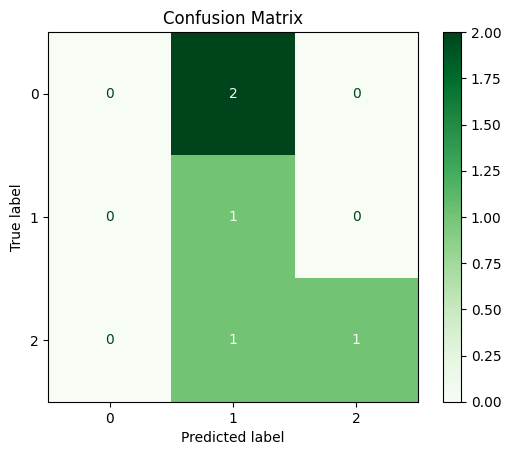

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens")
plt.title("Confusion Matrix")
plt.show()

In [38]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.25      1.00      0.40         1
           2       1.00      0.50      0.67         2

    accuracy                           0.40         5
   macro avg       0.42      0.50      0.36         5
weighted avg       0.45      0.40      0.35         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


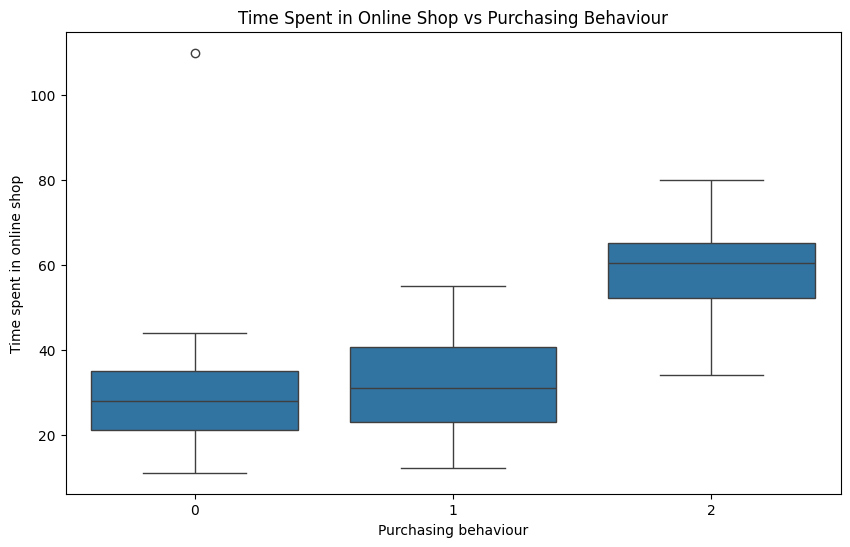

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.boxplot(
    x="Purchasing behaviour",
    y="Time spent in online shop",
    data=data
)
plt.title("Time Spent in Online Shop vs Purchasing Behaviour")
plt.show()